# QUSTION 1

In [2]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Subset the data for faster training
x_train_subset = x_train[:10000]
y_train_subset = y_train[:10000].flatten()
x_test_subset = x_test[:2000]
y_test_subset = y_test[:2000].flatten()

# Normalize the data
x_train_subset = x_train_subset.astype('float32') / 255.0
x_test_subset = x_test_subset.astype('float32') / 255.0

# Flatten the images for SVM and Random Forest
x_train_flattened = x_train_subset.reshape(x_train_subset.shape[0], -1)
x_test_flattened = x_test_subset.reshape(x_test_subset.shape[0], -1)

# Train an SVM model
svm_model = SVC(kernel='linear', C=1, random_state=42)
svm_model.fit(x_train_flattened, y_train_subset)

# Evaluate the SVM model
svm_predictions = svm_model.predict(x_test_flattened)
svm_accuracy = accuracy_score(y_test_subset, svm_predictions)
print("SVM Test Accuracy (Subset):", svm_accuracy)

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_flattened, y_train_subset)

# Evaluate the Random Forest model
rf_predictions = rf_model.predict(x_test_flattened)
rf_accuracy = accuracy_score(y_test_subset, rf_predictions)
print("Random Forest Test Accuracy (Subset):", rf_accuracy)


SVM Test Accuracy (Subset): 0.3355
Random Forest Test Accuracy (Subset): 0.434


# QUSTION 2 

In [8]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Subset the data
x_train_subset = x_train[:10000]
y_train_subset = y_train[:10000]
x_test_subset = x_test[:2000]
y_test_subset = y_test[:2000]

# Normalize pixel values to range [0, 1]
x_train_subset = x_train_subset.astype('float32') / 255.0
x_test_subset = x_test_subset.astype('float32') / 255.0

# One-hot encode labels
y_train_subset = to_categorical(y_train_subset, 10)
y_test_subset = to_categorical(y_test_subset, 10)

# Build ANN model
ann_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the ANN model
ann_model.fit(x_train_subset, y_train_subset, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate the ANN model
ann_test_loss, ann_test_accuracy = ann_model.evaluate(x_test_subset, y_test_subset)
print(f"ANN Test Accuracy: {ann_test_accuracy}")
from tensorflow.keras.layers import Conv2D, MaxPooling2D

# Build CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile the CNN model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_model.fit(x_train_subset, y_train_subset, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate the CNN model
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(x_test_subset, y_test_subset)
print(f"CNN Test Accuracy: {cnn_test_accuracy}")



Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1476 - loss: 2.5827 - val_accuracy: 0.2375 - val_loss: 2.0535
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2235 - loss: 2.0729 - val_accuracy: 0.2715 - val_loss: 1.9962
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2308 - loss: 2.0350 - val_accuracy: 0.2595 - val_loss: 2.0138
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2353 - loss: 2.0259 - val_accuracy: 0.2860 - val_loss: 1.9507
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2430 - loss: 2.0131 - val_accuracy: 0.3005 - val_loss: 1.9157
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3102 - loss: 1.9057
ANN Test Accuracy: 0.3100000023841858
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.1636 - loss: 2.2114 - val_accuracy: 0.3055 - val_loss: 1.8370
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3320 - loss: 1.8259 - val_accuracy: 0.4060 - val_loss: 

#  QUSTION 3 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

==================== SVM Evaluation ====================


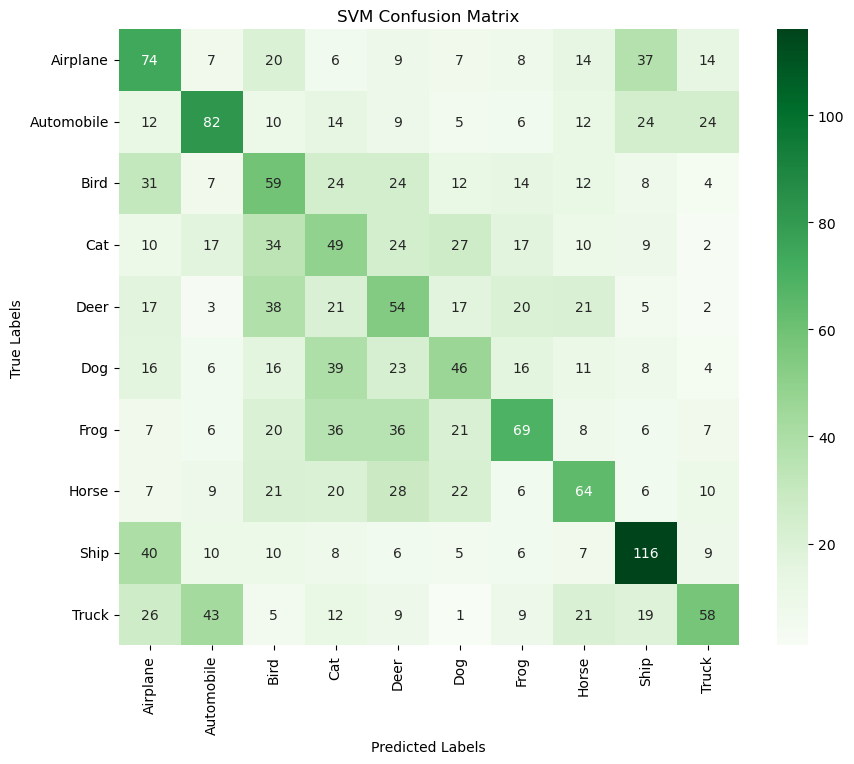

Classification Report for SVM:

              precision    recall  f1-score   support

    Airplane       0.31      0.38      0.34       196
  Automobile       0.43      0.41      0.42       198
        Bird       0.25      0.30      0.28       195
         Cat       0.21      0.25      0.23       199
        Deer       0.24      0.27      0.26       198
         Dog       0.28      0.25      0.26       185
        Frog       0.40      0.32      0.36       216
       Horse       0.36      0.33      0.34       193
        Ship       0.49      0.53      0.51       217
       Truck       0.43      0.29      0.34       203

    accuracy                           0.34      2000
   macro avg       0.34      0.33      0.33      2000
weighted avg       0.34      0.34      0.34      2000

IoU per class for SVM:
{'Airplane': 0.2044, 'Automobile': 0.268, 'Bird': 0.1599, 'Cat': 0.1293, 'Deer': 0.1475, 'Dog': 0.1523, 'Frog': 0.217, 'Horse': 0.2071, 'Ship': 0.3422, 'Truck': 0.2079}


===============

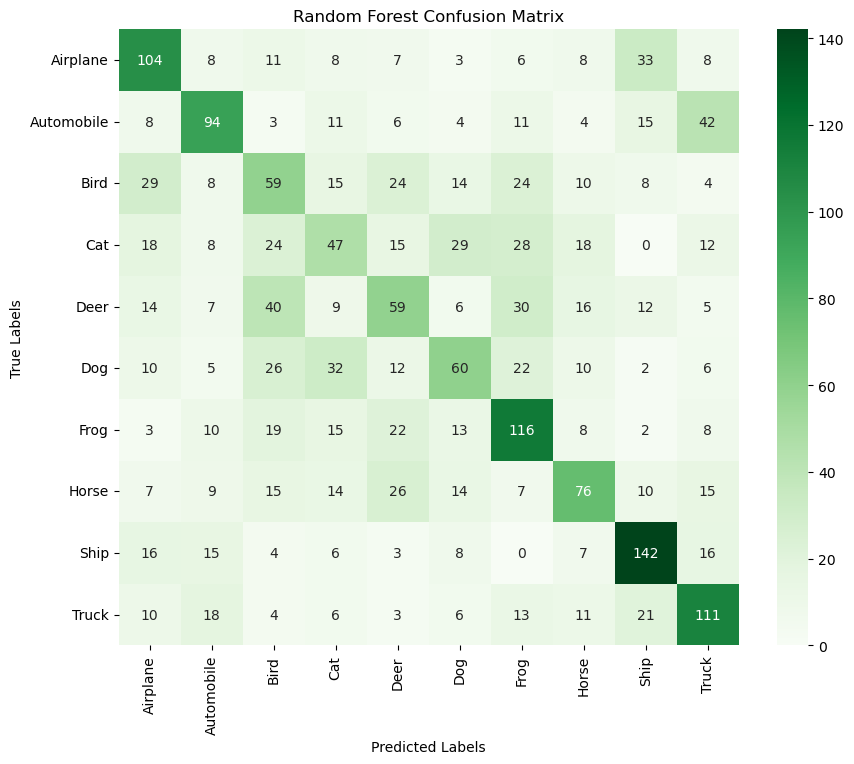

Classification Report for Random Forest:

              precision    recall  f1-score   support

    Airplane       0.47      0.53      0.50       196
  Automobile       0.52      0.47      0.49       198
        Bird       0.29      0.30      0.29       195
         Cat       0.29      0.24      0.26       199
        Deer       0.33      0.30      0.31       198
         Dog       0.38      0.32      0.35       185
        Frog       0.45      0.54      0.49       216
       Horse       0.45      0.39      0.42       193
        Ship       0.58      0.65      0.61       217
       Truck       0.49      0.55      0.52       203

    accuracy                           0.43      2000
   macro avg       0.43      0.43      0.43      2000
weighted avg       0.43      0.43      0.43      2000

IoU per class for Random Forest:
{'Airplane': 0.3344, 'Automobile': 0.3287, 'Bird': 0.173, 'Cat': 0.1492, 'Deer': 0.1867, 'Dog': 0.2128, 'Frog': 0.3249, 'Horse': 0.2667, 'Ship': 0.4438, 'Truck': 0.34

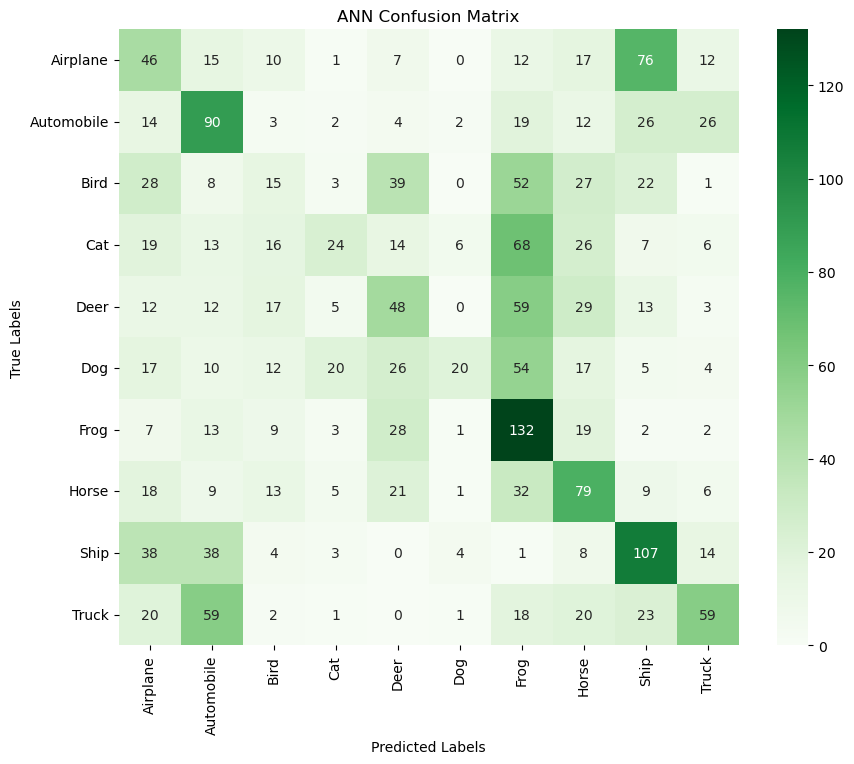

Classification Report for ANN:

              precision    recall  f1-score   support

    Airplane       0.21      0.23      0.22       196
  Automobile       0.34      0.45      0.39       198
        Bird       0.15      0.08      0.10       195
         Cat       0.36      0.12      0.18       199
        Deer       0.26      0.24      0.25       198
         Dog       0.57      0.11      0.18       185
        Frog       0.30      0.61      0.40       216
       Horse       0.31      0.41      0.35       193
        Ship       0.37      0.49      0.42       217
       Truck       0.44      0.29      0.35       203

    accuracy                           0.31      2000
   macro avg       0.33      0.30      0.28      2000
weighted avg       0.33      0.31      0.29      2000

IoU per class for ANN:
{'Airplane': 0.1247, 'Automobile': 0.24, 'Bird': 0.0534, 'Cat': 0.0992, 'Deer': 0.1424, 'Dog': 0.1, 'Frog': 0.2486, 'Horse': 0.2147, 'Ship': 0.2675, 'Truck': 0.213}


===================

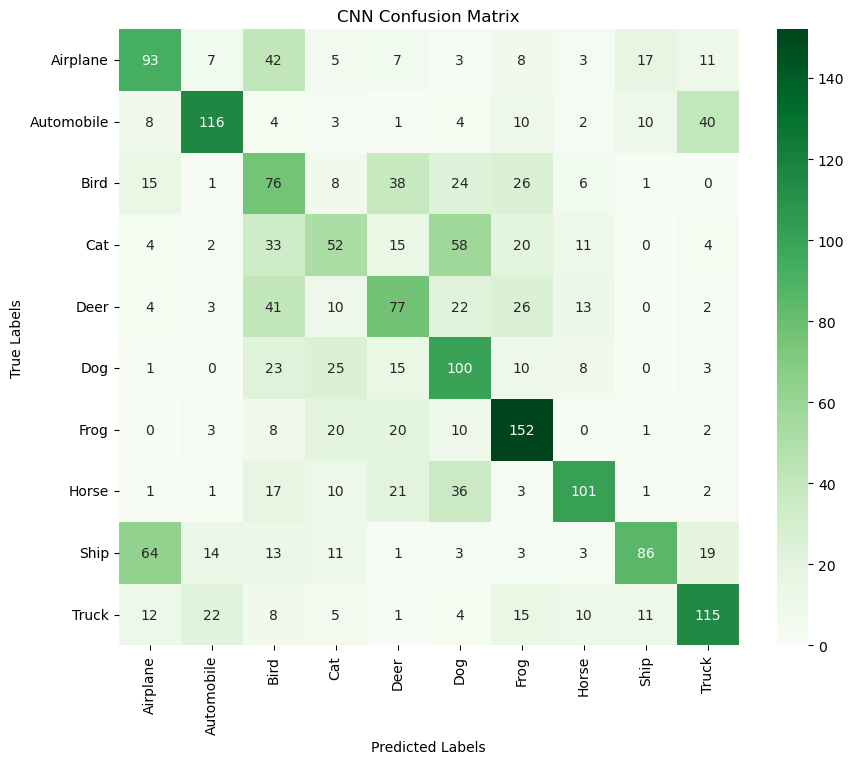

Classification Report for CNN:

              precision    recall  f1-score   support

    Airplane       0.46      0.47      0.47       196
  Automobile       0.69      0.59      0.63       198
        Bird       0.29      0.39      0.33       195
         Cat       0.35      0.26      0.30       199
        Deer       0.39      0.39      0.39       198
         Dog       0.38      0.54      0.45       185
        Frog       0.56      0.70      0.62       216
       Horse       0.64      0.52      0.58       193
        Ship       0.68      0.40      0.50       217
       Truck       0.58      0.57      0.57       203

    accuracy                           0.48      2000
   macro avg       0.50      0.48      0.48      2000
weighted avg       0.50      0.48      0.49      2000

IoU per class for CNN:
{'Airplane': 0.3049, 'Automobile': 0.4622, 'Bird': 0.1979, 'Cat': 0.1757, 'Deer': 0.2429, 'Dog': 0.2865, 'Frog': 0.451, 'Horse': 0.4056, 'Ship': 0.3333, 'Truck': 0.4021}



In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Function to plot confusion matrix
def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(title)
    plt.show()

# Function to calculate IoU for each class
def calculate_iou(cm):
    """
    Calculate IoU for each class from the confusion matrix.

    Parameters:
    cm (ndarray): Confusion matrix

    Returns:
    iou_per_class (dict): IoU scores for each class
    """
    iou_per_class = {}
    for i in range(len(cm)):
        true_positive = cm[i, i]
        false_positive = cm[:, i].sum() - true_positive
        false_negative = cm[i, :].sum() - true_positive
        union = true_positive + false_positive + false_negative
        iou_per_class[i] = true_positive / union if union > 0 else 0.0
    return iou_per_class

# CIFAR-10 class names
cifar10_classes = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"]

y_test_subset_true = np.argmax(y_test_subset, axis=1)
ann_predictions = np.argmax(ann_model.predict(x_test_subset), axis=1)
cnn_predictions = np.argmax(cnn_model.predict(x_test_subset), axis=1)

models = {
    "SVM": svm_predictions,
    "Random Forest": rf_predictions,
    "ANN": ann_predictions,
    "CNN": cnn_predictions,
}

for model_name, predictions in models.items():
    print(f"\n{'=' * 20} {model_name} Evaluation {'=' * 20}")
    
    # Generate confusion matrix
    cm = confusion_matrix(y_test_subset_true, predictions)
    plot_confusion_matrix(cm, cifar10_classes, f"{model_name} Confusion Matrix")
    
    # Print classification report
    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_test_subset_true, predictions, target_names=cifar10_classes))
    
    
    iou_scores = calculate_iou(cm)
    iou_scores_classes = {cifar10_classes[k]: round(v, 4) for k, v in iou_scores.items()}
    print(f"IoU per class for {model_name}:\n{iou_scores_classes}\n")
